In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_excel('churn_dataset.xlsx')
df.head(5)

,Age,Tenure,Sex,Churn
0,56,8,Male,No
1,46,63,Female,No
2,32,11,Female,No
3,60,8,Male,No
4,25,35,Male,No


In [7]:
df.isnull().sum()

Age       0
Tenure    0
Sex       0
Churn     0
dtype: int64

In [14]:
df.replace({'Sex': {'Male': 1, 'Female': 0}, 'Churn': {'No': 0, 'Yes': 1}}, inplace=True)

In [15]:
X, y = df.iloc[:, :3], df.iloc[:, -1]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [18]:
y_pred = model.predict(X_test)

In [19]:
acc = accuracy_score(y_test, y_pred)
acc

0.8

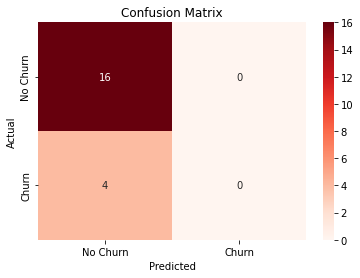

In [21]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
# no predicted "Churn" at all — it’s biased towards the "No Churn" class.
#imbalance problem.

In [26]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
f1

0.0

In [27]:
import joblib

In [28]:
joblib.dump(model, "NBmodel")

['NBmodel']